In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
compute_wc_vs_beta.py   数据保存在wc_experiment_out文件夹

计算并绘制 Herd Immunity Threshold (HIT) w_c 随 感染率 beta 变化的曲线。
比较删除策略：阈值删除 (Theta_del = 0.2,0.4,0.6) 与随机删除 (random control)。

输出：
 - out_dir/wc_perrun.csv   : 每次重复的结果（每行一条 run）
 - out_dir/wc_summary.csv  : 汇总（按 deletion_type, theta_del, beta 分组），含 mean_wc/std_wc/count_found
"""

import os
import time
import math
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# -------------------- 超图生成器（与你之前的实现一致） --------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------- MMCA 带删除策略（与你之前代码相同的行为） --------------------
class MMCAWithDeletion:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0].copy()
        self.edge_j = self.hyperedges[:,1].copy()
        self.edge_k = self.hyperedges[:,2].copy()
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def run_mmca_with_deletion(self,
                               beta_d, mu, eta, gamma,
                               deletion_type='threshold',
                               theta_del=None,
                               w=0.0,
                               init_frac=0.01,
                               tol=1e-8, max_iter=2000,
                               rng_seed=None,
                               threshold_delete_selection='closest_to_threshold'):
        """
        与之前行为保持一致：
         - deletion_type='random'：初始一次性删除 budget=floor(w*m) 条边
         - deletion_type='threshold'：动态删除 Theta_next < theta_del 的候选，直到达到预算
        返回 dict，包含 rho_final、f_del、num_deleted
        """
        rng = np.random.RandomState(rng_seed) if rng_seed is not None else np.random

        n = self.n; m = self.m
        p = np.full(n, init_frac, dtype=float)
        Theta = np.ones(m, dtype=float)

        deletion_budget = int(math.floor(float(w) * m))
        if deletion_budget >= m:
            if m > 1:
                deletion_budget = m - 1
            else:
                deletion_budget = 0

        active = np.ones(m, dtype=bool)
        deleted_count = 0

        # random 一次性删除
        if deletion_type == 'random' and deletion_budget > 0:
            del_idx = rng.choice(m, size=deletion_budget, replace=False)
            active[del_idx] = False
            Theta[~active] = 0.0
            deleted_count = int((~active).sum())

        rho_hist = []
        iters = 0

        for it in range(max_iter):
            rho_hist.append(p.mean())

            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            Q = np.ones(n, dtype=float)
            for node in range(n):
                prod_val = 1.0
                for (ei, pos) in self.node_edge_pos[node]:
                    if not active[ei]:
                        continue
                    if pos == 0:
                        oth = prod_pos0[ei]
                    elif pos == 1:
                        oth = prod_pos1[ei]
                    else:
                        oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p

            # Theta 更新
            if active.any():
                p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
                Phi = p_i * p_j * p_k
                Theta_next = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
                Theta_next = np.clip(Theta_next, 0.0, 1.0)
                Theta_next[~active] = 0.0
            else:
                Theta_next = Theta.copy()

            # threshold 策略尝试删除（受 budget 限制）
            if deletion_type == 'threshold' and (theta_del is not None) and deletion_budget > 0 and deleted_count < deletion_budget:
                cand = np.where((Theta_next < theta_del) & active)[0]
                if cand.size > 0:
                    remaining = deletion_budget - deleted_count
                    if cand.size <= remaining:
                        to_delete = cand
                    else:
                        if threshold_delete_selection == 'random':
                            to_delete = rng.choice(cand, size=remaining, replace=False)
                        elif threshold_delete_selection == 'lowest_theta':
                            order = np.argsort(Theta_next[cand])
                            to_delete = cand[order[:remaining]]
                        else:  # closest_to_threshold (默认)：优先删除 Theta 值较大（最接近阈值）
                            order = np.argsort(-Theta_next[cand])
                            to_delete = cand[order[:remaining]]
                    active[to_delete] = False
                    Theta_next[to_delete] = 0.0
                    deleted_count += to_delete.size

            dp = np.max(np.abs(p_next - p))
            dTheta = np.max(np.abs(Theta_next - Theta)) if active.any() else 0.0
            p = p_next
            Theta = Theta_next
            iters = it + 1

            if dp < tol and dTheta < tol:
                break

        rho_final = float(p.mean())
        num_deleted = int((~active).sum())
        f_del = float(num_deleted) / float(m)

        return {
            'rho_final': rho_final,
            'iters': iters,
            'num_deleted': num_deleted,
            'f_del': f_del,
            'rho_hist': np.array(rho_hist),
            'active_mask': active.copy()
        }

# -------------------- 单个任务：在一张图上对 w_list 顺序查找 w_c --------------------
def find_wc_on_one_graph(hyperedges, n, deletion_type, theta_del, beta, w_list,
                         mu, eta, gamma, init_frac, tol, max_iter, rng_seed, rho_thresh,
                         threshold_delete_selection):
    """
    给定一张 hypergraph（hyperedges），在 ascending w_list 上依次运行 MMCAWithDeletion，
    返回第一个使 rho_final <= rho_thresh 的 w（称为 w_c）。若无，则返回 np.nan。
    该函数在单个进程中顺序执行 w_list，适用于 threshold 策略重用同一张图。
    """
    model = MMCAWithDeletion(hyperedges, n)
    # 对 random 策略：每次运行会在内部随机选择要删除的边（rng_seed 可以不同）
    for iw, w in enumerate(sorted(w_list)):
        # 不同 w 使用不同的 rng_seed（保证可复现）
        run_seed = None if rng_seed is None else (int(rng_seed) + iw)
        res = model.run_mmca_with_deletion(
            beta_d=beta, mu=mu, eta=eta, gamma=gamma,
            deletion_type=deletion_type, theta_del=theta_del, w=w,
            init_frac=init_frac, tol=tol, max_iter=max_iter,
            rng_seed=run_seed, threshold_delete_selection=threshold_delete_selection
        )
        rho_final = res['rho_final']
        if rho_final <= rho_thresh:
            return {
                'w_c': float(w),
                'found': True,
                'rho_final': float(rho_final),
                'num_deleted': int(res['num_deleted'])
            }
    # 没有找到使 rho <= rho_thresh 的 w
    return {
        'w_c': float('nan'),
        'found': False,
        'rho_final': float(rho_final),  # 最后一个 w 的 rho_final
        'num_deleted': int(res['num_deleted'])
    }

# -------------------- worker：生成超图并在其上寻找 w_c --------------------
def worker_task(args):
    """
    args: tuple containing
      (deletion_type, theta_del, beta, run_index, n, kappa, w_list,
       mu, eta, gamma, init_frac, tol, max_iter, seed_base, rho_thresh, threshold_delete_selection)
    返回 per-run 字典
    """
    (deletion_type, theta_del, beta, r, n, kappa, w_list,
     mu, eta, gamma, init_frac, tol, max_iter, seed_base, rho_thresh, threshold_delete_selection) = args

    gen_seed = None if seed_base is None else int(seed_base + r)
    # 生成 hypergraph（同一 run 对所有 w 使用同一张图 --> 对 threshold 策略很重要）
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed, batch_size=3000)
    # rng seed 为可复现的偏移
    rng_seed_base = None if seed_base is None else int(seed_base + 100000 + r)

    result = find_wc_on_one_graph(hyperedges=hyperedges, n=n,
                                  deletion_type=deletion_type, theta_del=theta_del, beta=beta,
                                  w_list=w_list, mu=mu, eta=eta, gamma=gamma,
                                  init_frac=init_frac, tol=tol, max_iter=max_iter,
                                  rng_seed=rng_seed_base, rho_thresh=rho_thresh,
                                  threshold_delete_selection=threshold_delete_selection)

    out = {
        'deletion_type': deletion_type,
        'theta_del': (theta_del if deletion_type == 'threshold' else -1.0),
        'beta': float(beta),
        'run': int(r),
        'w_c': result['w_c'],
        'found': bool(result['found']),
        'rho_final_at_wc': float(result['rho_final']),
        'num_deleted_at_wc': int(result['num_deleted'])
    }
    return out

# -------------------- 主驱动：构建任务并并行执行 --------------------
def compute_wc_vs_beta(n, kappa, betas, theta_list, w_list,
                       mu, eta, gamma, init_frac,
                       tol, max_iter, R, seed_base,
                       rho_thresh, n_jobs, out_dir, threshold_delete_selection='closest_to_threshold'):
    os.makedirs(out_dir, exist_ok=True)
    tasks = []
    # 构建任务：对每个 theta（包括 'random'）和 beta 做 R 次重复
    for theta_del in theta_list:
        for beta in betas:
            for r in range(R):
                tasks.append(('threshold', float(theta_del), float(beta), int(r),
                              n, kappa, w_list,
                              mu, eta, gamma, init_frac, tol, max_iter, seed_base, rho_thresh, threshold_delete_selection))
    # random 对照：我们以 deletion_type='random' 复用 w_list 作为预算列表
    for beta in betas:
        for r in range(R):
            tasks.append(('random', float('nan'), float(beta), int(r),
                          n, kappa, w_list,
                          mu, eta, gamma, init_frac, tol, max_iter, seed_base, rho_thresh, threshold_delete_selection))

    print(f"[INFO] 总任务数 = {len(tasks)}  (theta points {len(theta_list)}, beta points {len(betas)}, R={R})")
    t0 = time.time()
    results = Parallel(n_jobs=n_jobs, verbose=10)(delayed(worker_task)(task) for task in tasks)
    elapsed = time.time() - t0
    print(f"[INFO] 并行完成，耗时 {elapsed:.1f}s")

    df = pd.DataFrame(results)
    perrun_fn = os.path.join(out_dir, "wc_perrun.csv")
    df.to_csv(perrun_fn, index=False, float_format="%.6f")
    print(f"[INFO] 已保存 per-run -> {perrun_fn}")

    # 汇总（按 deletion_type, theta_del, beta）
    # 注意 random 的 theta_del 为 NaN（保留）
    def label_theta(x):
        return 'random' if np.isnan(x) else f"{float(x):.2f}"

    # group and compute mean/std only over found runs (exclude NaN w_c)
    df_found = df[df['found'] == True].copy()
    summary = df_found.groupby(['deletion_type', 'theta_del', 'beta']).agg(
        mean_wc=('w_c', 'mean'),
        std_wc=('w_c', 'std'),
        count_found=('w_c', 'count')
    ).reset_index().sort_values(['deletion_type', 'theta_del', 'beta'])

    summary_fn = os.path.join(out_dir, "wc_summary.csv")
    summary.to_csv(summary_fn, index=False, float_format="%.6f")
    print(f"[INFO] 已保存 summary -> {summary_fn}")

    return df, summary

# -------------------- 参数区（按需调整） --------------------
# 网络 / 模型
n = 1500
kappa = 6.0

# beta 范围（0.2 - 0.4）
betas = np.linspace(0.24, 0.40, 17)  # 11 点，可改为更密

# 要比较的阈值 Theta_c（以及 random 对照会在最后绘制）
theta_list = [0.2, 0.4, 0.6]

# w 网格（上界 0..1），从小到大扫描寻找最小能灭绝的 w
w_list = np.concatenate([
    np.arange(0.00, 0.50, 0.05),  # 粗
    np.arange(0.50, 0.70, 0.02),  # 中间精细
    np.arange(0.70, 1.00, 0.05)   # 大范围
])

# epidemic / Theta 参数
mu = 0.1
eta = 0.6
gamma = 0.02

# 计算控制
R = 5               # 每组 (beta, theta) 的重复次数（独立图）
init_frac = 0.3
tol = 1e-6
max_iter = 1200
seed_base = 12345

# 判定"灭绝"的阈值
rho_thresh = 1e-4

# 并行与输出
n_jobs = 18           # 根据你的 CPU 调整
out_dir = "wc_experiment_out"
threshold_delete_selection = 'closest_to_threshold'  # or 'lowest_theta' or 'random'

# -------------------- 运行 --------------------
if __name__ == "__main__":
    t0 = time.time()
    perrun_df, summary_df = compute_wc_vs_beta(
        n=n, kappa=kappa, betas=betas, theta_list=theta_list, w_list=w_list,
        mu=mu, eta=eta, gamma=gamma, init_frac=init_frac,
        tol=tol, max_iter=max_iter, R=R, seed_base=seed_base,
        rho_thresh=rho_thresh, n_jobs=n_jobs, out_dir=out_dir,
        threshold_delete_selection=threshold_delete_selection
    )
    print("汇总（部分预览）：")
    print(summary_df.head(30))
    print("计算完成，耗时 {:.1f}s".format(time.time() - t0))

[INFO] 总任务数 = 340  (theta points 3, beta points 17, R=5)


[Parallel(n_jobs=18)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   5 tasks      | elapsed:   39.5s
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:   41.0s
[Parallel(n_jobs=18)]: Done  25 tasks      | elapsed:  1.4min
[Parallel(n_jobs=18)]: Done  36 tasks      | elapsed:  1.5min
[Parallel(n_jobs=18)]: Done  49 tasks      | elapsed:  2.2min
[Parallel(n_jobs=18)]: Done  62 tasks      | elapsed:  3.0min
[Parallel(n_jobs=18)]: Done  77 tasks      | elapsed:  3.9min
[Parallel(n_jobs=18)]: Done  92 tasks      | elapsed:  4.5min
[Parallel(n_jobs=18)]: Done 109 tasks      | elapsed:  5.2min
[Parallel(n_jobs=18)]: Done 126 tasks      | elapsed:  6.2min
[Parallel(n_jobs=18)]: Done 145 tasks      | elapsed:  7.3min
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:  8.4min
[Parallel(n_jobs=18)]: Done 185 tasks      | elapsed:  9.2min
[Parallel(n_jobs=18)]: Done 206 tasks      | elapsed: 10.7min
[Parallel(n_jobs=18)]: Done 229 tasks      | elapsed: 1

[INFO] 并行完成，耗时 1179.4s
[INFO] 已保存 per-run -> wc_experiment_out\wc_perrun.csv
[INFO] 已保存 summary -> wc_experiment_out\wc_summary.csv
汇总（部分预览）：
   deletion_type  theta_del  beta  mean_wc    std_wc  count_found
0         random       -1.0  0.24    0.352  0.010954            5
1         random       -1.0  0.25    0.380  0.000000            5
2         random       -1.0  0.26    0.416  0.008944            5
3         random       -1.0  0.27    0.448  0.010954            5
4         random       -1.0  0.28    0.472  0.010954            5
5         random       -1.0  0.29    0.500  0.000000            5
6         random       -1.0  0.30    0.528  0.010954            5
7         random       -1.0  0.31    0.552  0.010954            5
8         random       -1.0  0.32    0.572  0.010954            5
9         random       -1.0  0.33    0.596  0.008944            5
10        random       -1.0  0.34    0.616  0.008944            5
11        random       -1.0  0.35    0.632  0.010954            5


[Parallel(n_jobs=18)]: Done 340 out of 340 | elapsed: 19.7min finished


读取结果文件...
读取到 124 条汇总记录
读取到 340 条详细记录

汇总数据预览：
  deletion_type  theta_del  beta  mean_wc    std_wc  count_found
0        random       -1.0  0.25   0.3820  0.007579           40
1        random       -1.0  0.26   0.4140  0.009282           40
2        random       -1.0  0.27   0.4415  0.006998           40
3        random       -1.0  0.28   0.4715  0.010013           40
4        random       -1.0  0.29   0.5000  0.006405           40

绘制主图...
[INFO] 已保存图像 -> wc_experiment_out\wc_vs_beta.png


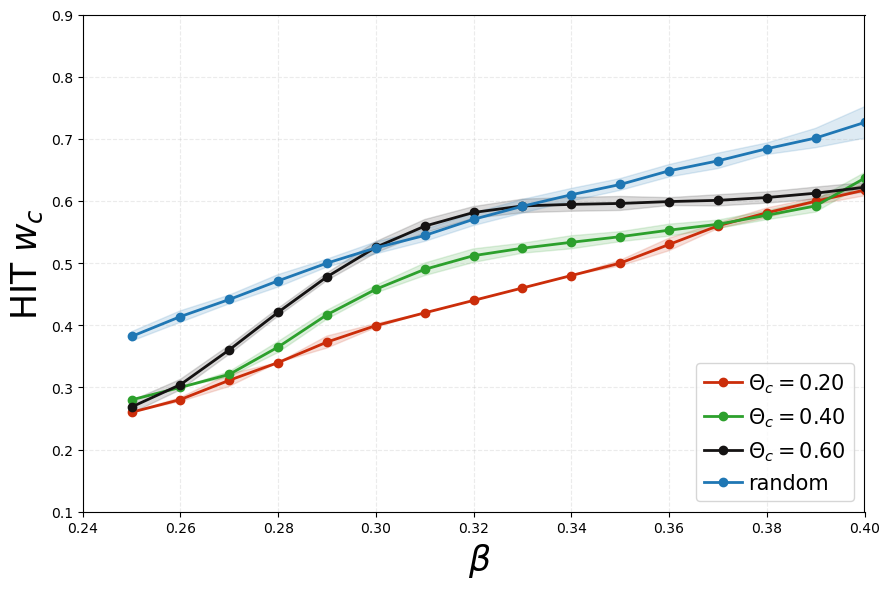

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
plot_wc_vs_beta.py

读取 compute_wc_vs_beta.py 的输出结果并绘制图形。
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 参数设置
out_dir = "wc_experiment_out"  # 与 compute_wc_vs_beta.py 中的 out_dir 一致

# 检查文件是否存在
summary_file = os.path.join(out_dir, "wc_summary1.csv")
perrun_file = os.path.join(out_dir, "wc_perrun.csv")

if not os.path.exists(summary_file):
    print(f"错误：找不到汇总文件 {summary_file}")
    print("请先运行 compute_wc_vs_beta.py 生成结果")

# 读取数据
print("读取结果文件...")
summary_df = pd.read_csv(summary_file)
perrun_df = pd.read_csv(perrun_file) if os.path.exists(perrun_file) else None

print(f"读取到 {len(summary_df)} 条汇总记录")
if perrun_df is not None:
    print(f"读取到 {len(perrun_df)} 条详细记录")

# 显示数据预览
print("\n汇总数据预览：")
print(summary_df.head())

# 绘制主图
print("\n绘制主图...")
colors = ['#1f77b4', "#cb2d0a", '#2ca02c', "#151313",]

plt.figure(figsize=(9,6))
# 构建标签顺序：theta_del 数值升序 + random 放最后
unique_keys = []
# numeric theta
numeric_keys = sorted([k for k in summary_df['theta_del'].unique() if not np.isnan(k)])
for th in numeric_keys:
    unique_keys.append(('threshold', float(th)))
# random
unique_keys.append(('random', np.nan))

for i, key in enumerate(unique_keys):
    del_type, th = key
    if del_type == 'random':
        sub = summary_df[summary_df['deletion_type'] == 'random']
        label = 'random'
    else:
        sub = summary_df[(summary_df['deletion_type']=='threshold') & (np.isclose(summary_df['theta_del'], th))]
        label = fr"$\Theta_c={th:.2f}$"
    if sub.empty:
        continue
    sub = sub.sort_values('beta')
    x = sub['beta'].to_numpy()
    y = sub['mean_wc'].to_numpy()
    yerr = sub['std_wc'].fillna(0.0).to_numpy() if 'std_wc' in sub.columns else np.zeros_like(y)
    color = colors[i % len(colors)]
    plt.plot(x, y, marker='o', color=color, linewidth=2, label=label)
    if np.any(yerr > 0):
        plt.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)

plt.xlabel(r' $\beta$', fontsize=25)
plt.ylabel(r'HIT $w_c$', fontsize=25)
# plt.title(r'HIT $w_c$ vs $\beta$ for different deletion strategies', fontsize=14)
plt.ylim(0.1, 0.9)
plt.xlim(0.24, 0.40)
# plt.xlim(min(summary_df['beta']), max(summary_df['beta']))
plt.grid(alpha=0.25, linestyle='--')

legend = plt.legend(
    loc='lower right',
    # bbox_to_anchor=(1, 0.55),
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    # ncol=2,              # 分两列
    handlelength=1.8,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)

plt.tight_layout()
fig_fn = os.path.join(out_dir, "wc_vs_beta.png")
plt.savefig(fig_fn, dpi=300, bbox_inches='tight')
print(f"[INFO] 已保存图像 -> {fig_fn}")
plt.show()

